# **Project 1: E-Commerce Sales Anlaysis**


## **Preprocessing data**

### **Import library**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Display options
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore.csv


### **Understanding data**

Dataset terdiri dari 9.994 transaksi dengan 13 variabel yang mencakup informasi pelanggan, lokasi, kategori produk, penjualan, diskon, dan profit.

Hasil pemeriksaan menunjukkan bahwa tidak terdapat missing values sehingga data siap untuk dianalisis lebih lanjut.

Statistik deskriptif menunjukkan bahwa distribusi penjualan bersifat right-skewed, ditandai dengan rata-rata penjualan (229.86) yang jauh lebih tinggi daripada median (54.49). Selain itu, terdapat transaksi dengan profit negatif yang cukup besar sehingga diperlukan analisis lebih lanjut terhadap pengaruh kategori produk dan diskon terhadap profit.

In [3]:
df = pd.read_csv("SampleSuperstore.csv")

In [4]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [7]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [9]:
df.duplicated().sum()

np.int64(17)

###**Data Cleaning & Feature Engineering**

In [10]:
# Membuat salinan dataset
df_clean = df.copy()

In [11]:
df_clean.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [12]:
df_clean.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [13]:
df_clean.duplicated().sum()

np.int64(17)

In [14]:
df_clean = df_clean.drop_duplicates()

In [15]:
df_clean.duplicated().sum()

np.int64(0)

In [16]:
df_clean.shape

(9977, 13)

In [17]:
df_clean["Profit Margin (%)"] = (df_clean["Profit"] / df_clean["Sales"]) * 100

In [18]:
df_clean[["Sales", "Profit", "Profit Margin (%)"]].head()

,Sales,Profit,Profit Margin (%)
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [19]:
import numpy as np

df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

In [20]:
df_clean["Profit Margin (%)"].isnull().sum()

np.int64(0)

In [21]:
def discount_category(discount):
    if discount == 0:
        return "No Discount"
    elif discount <= 0.2:
        return "Low Discount"
    elif discount <= 0.5:
        return "Medium Discount"
    else:
        return "High Discount"

df_clean["Discount Category"] = df_clean["Discount"].apply(discount_category)

In [22]:
df_clean[["Discount", "Discount Category"]].head()

,Discount,Discount Category
0,0.00,No Discount
1,0.00,No Discount
2,0.00,No Discount
3,0.45,Medium Discount
4,0.20,Low Discount


In [23]:
def profit_status(profit):
    if profit > 0:
        return "Profit"
    elif profit < 0:
        return "Loss"
    else:
        return "Break Even"

df_clean["Profit Status"] = df_clean["Profit"].apply(profit_status)

In [24]:
df_clean["Profit Status"].value_counts()

,count
Profit Status,
Profit,8043
Loss,1869
Break Even,65


In [25]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9977 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ship Mode          9977 non-null   object 
 1   Segment            9977 non-null   object 
 2   Country            9977 non-null   object 
 3   City               9977 non-null   object 
 4   State              9977 non-null   object 
 5   Postal Code        9977 non-null   int64  
 6   Region             9977 non-null   object 
 7   Category           9977 non-null   object 
 8   Sub-Category       9977 non-null   object 
 9   Sales              9977 non-null   float64
 10  Quantity           9977 non-null   int64  
 11  Discount           9977 non-null   float64
 12  Profit             9977 non-null   float64
 13  Profit Margin (%)  9977 non-null   float64
 14  Discount Category  9977 non-null   object 
 15  Profit Status      9977 non-null   object 
dtypes: float64(4), int64(2), obje

In [26]:
df_clean.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin (%),Discount Category,Profit Status
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,No Discount,Profit
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,No Discount,Profit
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,No Discount,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,Medium Discount,Loss
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,Low Discount,Profit


### Data Cleaning

- Tidak ditemukan missing values.
- Ditemukan 17 baris duplikat yang kemudian dihapus.
- Seluruh tipe data sudah sesuai sehingga tidak memerlukan konversi.
- Dataset akhir berisi 9.977 transaksi yang siap dianalisis.

### Feature Engineering

Untuk mendukung analisis bisnis, dibuat tiga fitur baru:

- **Profit Margin (%)** untuk mengukur efisiensi keuntungan setiap transaksi.
- **Discount Category** untuk mengelompokkan tingkat diskon.
- **Profit Status** untuk membedakan transaksi yang menghasilkan keuntungan, kerugian, atau impas.

## **Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is performed to discover patterns, trends, and relationships within the data.

This section answers the business questions through descriptive statistics and data visualization.

In [27]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Postal Code,9977.0,55154.964117,32058.266816,1040.000,23223.0000,55901.000,90008.000,99301.000
Sales,9977.0,230.148902,623.721409,0.444,17.3000,54.816,209.970,22638.480
Quantity,9977.0,3.790719,2.226657,1.000,2.0000,3.000,5.000,14.000
Discount,9977.0,0.156278,0.206455,0.000,0.0000,0.200,0.200,0.800
Profit,9977.0,28.690130,234.457840,-6599.978,1.7262,8.671,29.372,8399.976
Profit Margin (%),9977.0,12.011354,46.663769,-275.000,7.5000,27.000,36.250,50.000


**Distribution of Sales**

This visualization shows how sales values are distributed across all transactions.

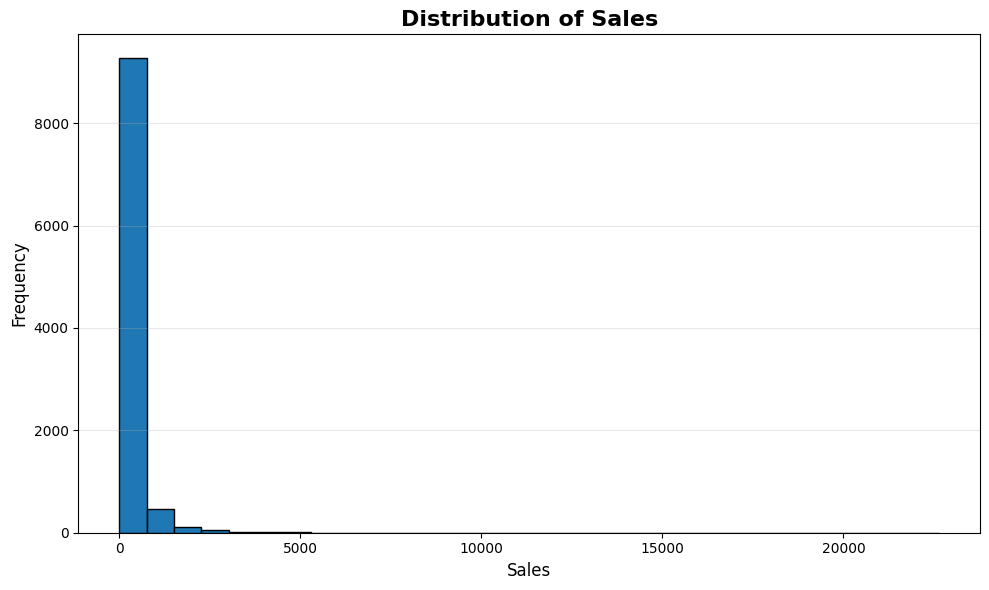

In [28]:
plt.figure(figsize=(10,6))

plt.hist(
    df_clean["Sales"],
    bins=30,
    edgecolor='black'
)

plt.title("Distribution of Sales", fontsize=16, fontweight='bold')
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

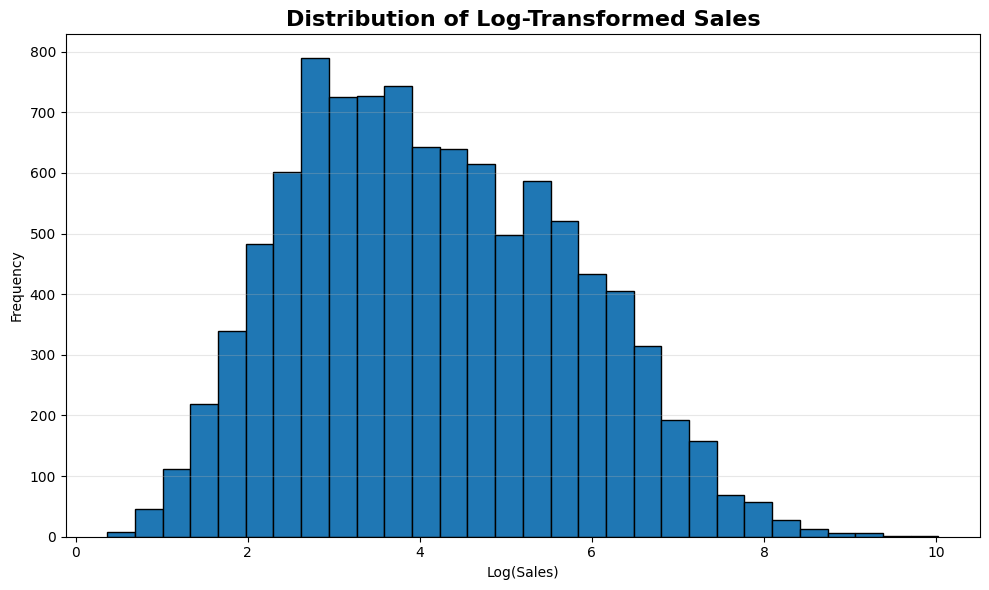

In [29]:
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(df_clean["Sales"]),
    bins=30,
    edgecolor='black'
)

plt.title("Distribution of Log-Transformed Sales", fontsize=16, fontweight='bold')
plt.xlabel("Log(Sales)")
plt.ylabel("Frequency")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

**Insight**

- The distribution of sales is highly right-skewed.

- Most transactions have relatively low sales values, while only a small number of transactions generate exceptionally high sales.

- This indicates that the company's revenue is heavily influenced by a limited number of high-value transactions. Therefore, management should identify the characteristics of these high-value transactions to maximize future sales opportunities.

----------------------------------

**Sales by Product Category**

(This analysis aims to identify which product category contributes the highest sales revenue.)

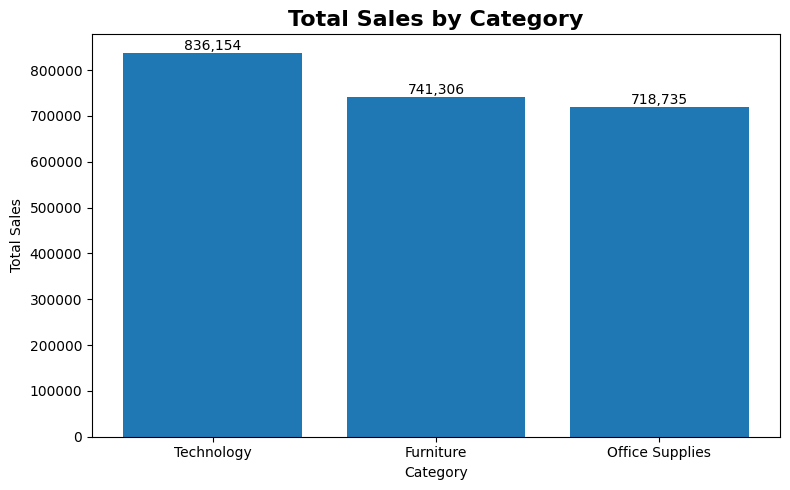

In [30]:
sales_category = (
    df_clean.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    sales_category.index,
    sales_category.values
)

plt.title("Total Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Menampilkan nilai di atas batang
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

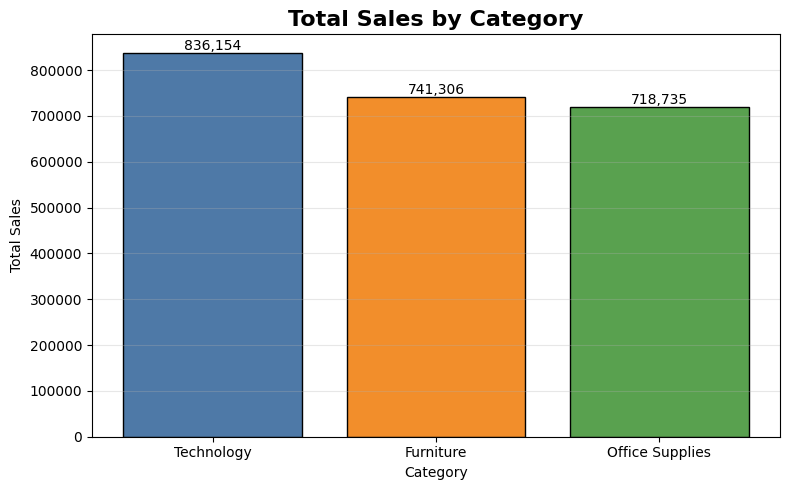

In [31]:
colors = ["#4E79A7", "#F28E2B", "#59A14F"]

plt.figure(figsize=(8,5))

bars = plt.bar(
    sales_category.index,
    sales_category.values,
    color=colors,
    edgecolor="black"
)

plt.title("Total Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Insight**

- Technology generated the highest total sales, contributing approximately **836,154**, making it the company's strongest revenue-generating category.

- Furniture ranked second with total sales of approximately **741,306**, while Office Supplies recorded the lowest total sales at approximately **718,735**.

- Although Technology leads in revenue, high sales do not necessarily indicate high profitability. Therefore, further analysis of profit by category is required to evaluate each category's financial performance.

**Business Impact**

- The company should continue investing in the Technology category through inventory planning, marketing campaigns, and product development.

- However, management should not rely solely on sales performance. Profitability analysis is required to determine whether the highest-selling category also generates the highest profit.

--------------------------------

**Profit by Product Category**

(This visualization compares the total profit generated by each product category.)

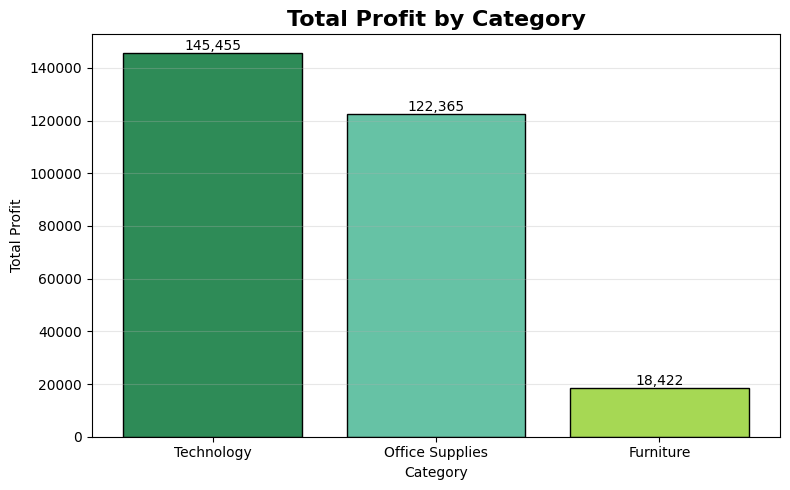

In [32]:
profit_category = (
    df_clean.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

colors = ["#2E8B57", "#66C2A5", "#A6D854"]

bars = plt.bar(
    profit_category.index,
    profit_category.values,
    color=colors,
    edgecolor="black"
)

plt.title("Total Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Which product category generates the highest profit?**

**Insight**

- Technology generated the highest total profit, reaching approximately **145,455**, making it the most profitable product category.

- Office Supplies ranked second with a total profit of approximately **122,365**, despite having the lowest total sales among the three categories.

- Furniture generated the lowest profit, approximately **18,422**, even though it recorded the second-highest sales.

- This indicates that high sales do not necessarily translate into high profitability. Furniture appears to have a significantly lower profit margin than the other categories.

**Business Impact**

- The company should continue investing in the Technology category, as it consistently delivers both high sales and high profitability.

- Although Furniture contributes substantially to total sales, its low profit suggests potential issues related to pricing strategy, production costs, or excessive discounting. Management should further investigate this category to improve its profitability.

- Office Supplies demonstrates a healthy balance between sales and profit, indicating efficient pricing and cost management.

------------------------------------

**Sales by Region**

(This analysis evaluates regional sales performance to identify high-performing regions.)



**Which region contributes the highest total sales?**

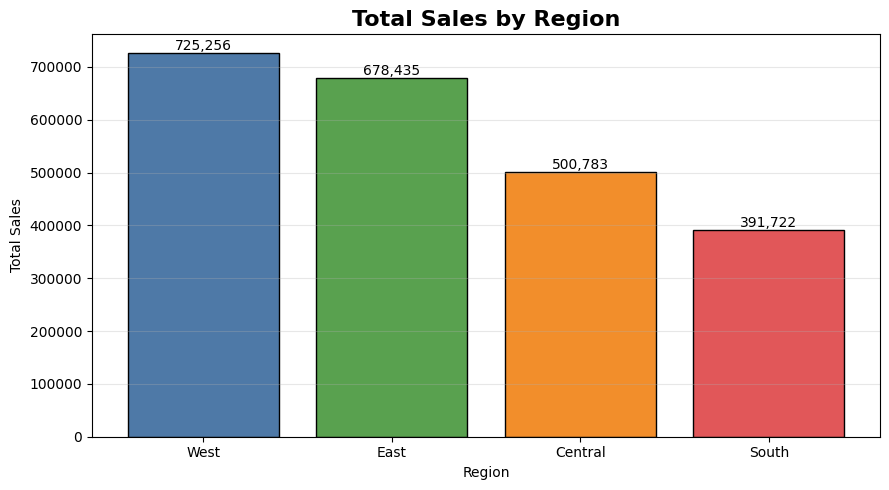

In [33]:
sales_region = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

colors = ["#4E79A7","#59A14F","#F28E2B","#E15759"]

bars = plt.bar(
    sales_region.index,
    sales_region.values,
    color=colors,
    edgecolor="black"
)

plt.title("Total Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.show()

----------------------------------

**Top 10 Cities by Sales**

(This visualization identifies the cities contributing the highest sales revenue.)

**Which cities contribute the highest sales?**

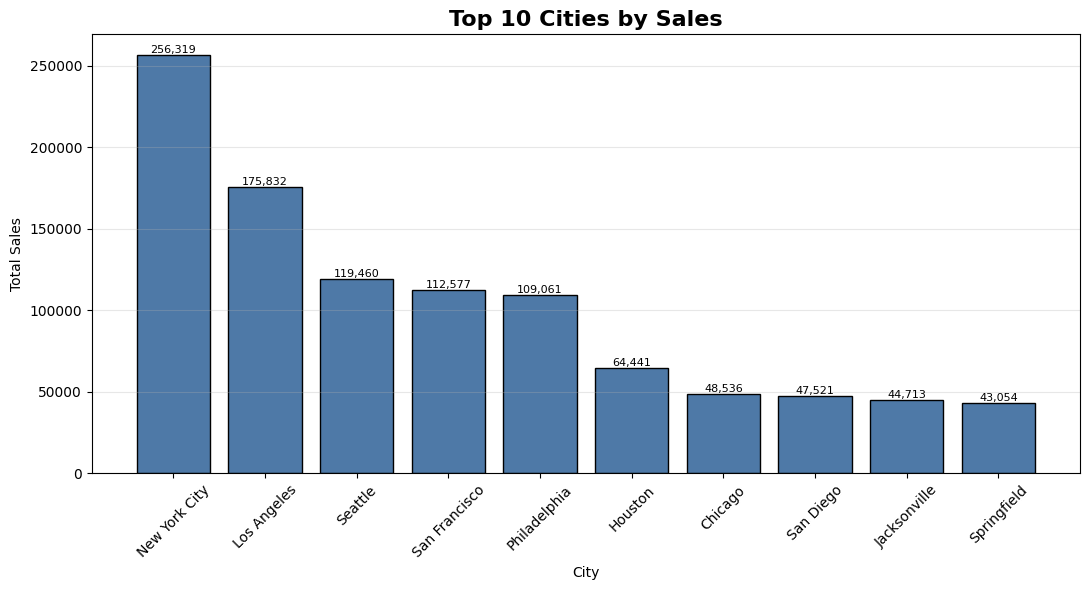

In [34]:
top_city = (
    df_clean.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

bars = plt.bar(
    top_city.index,
    top_city.values,
    color="#4E79A7",
    edgecolor="black"
)

plt.title("Top 10 Cities by Sales", fontsize=16, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

plt.show()

------------------------------

**Profit by Sub-Category**

(This analysis identifies which product sub-categories generate the highest and lowest profit.)

**Which product sub-categories generate the highest and lowest profit?**

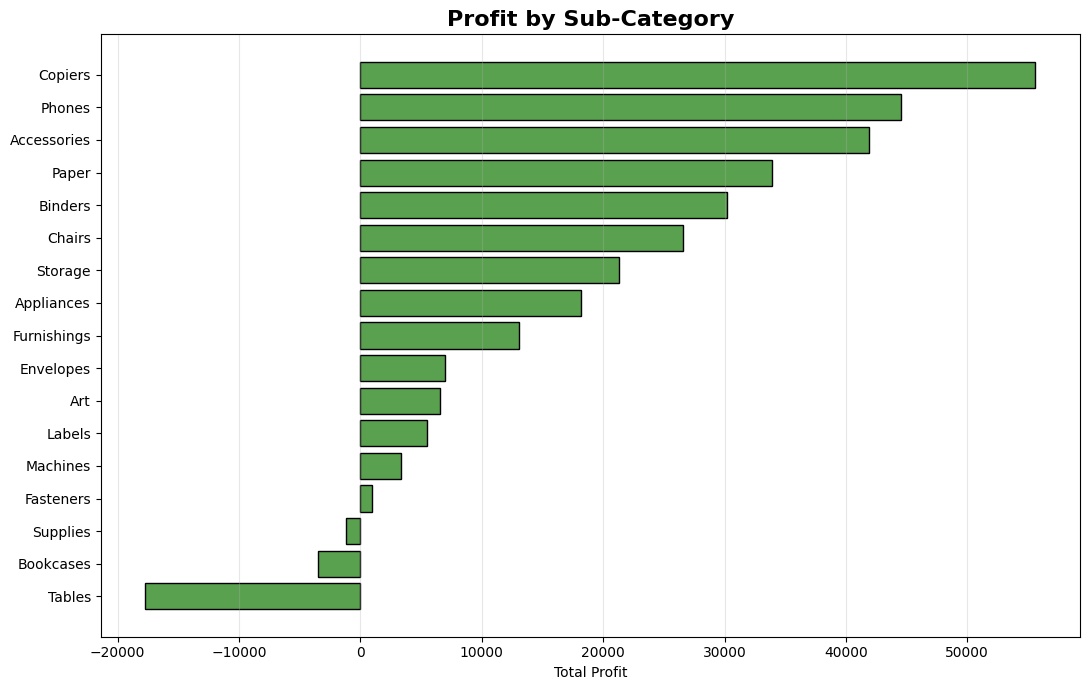

In [35]:
subcategory_profit = (
    df_clean.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(11,7))

bars = plt.barh(
    subcategory_profit.index,
    subcategory_profit.values,
    color="#59A14F",
    edgecolor="black"
)

plt.title("Profit by Sub-Category", fontsize=16, fontweight="bold")
plt.xlabel("Total Profit")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

-----------------------------

**Relationship Between Discount and Profit**

(This analysis investigates whether higher discounts lead to lower profitability.)

**Does increasing the discount reduce profitability?**

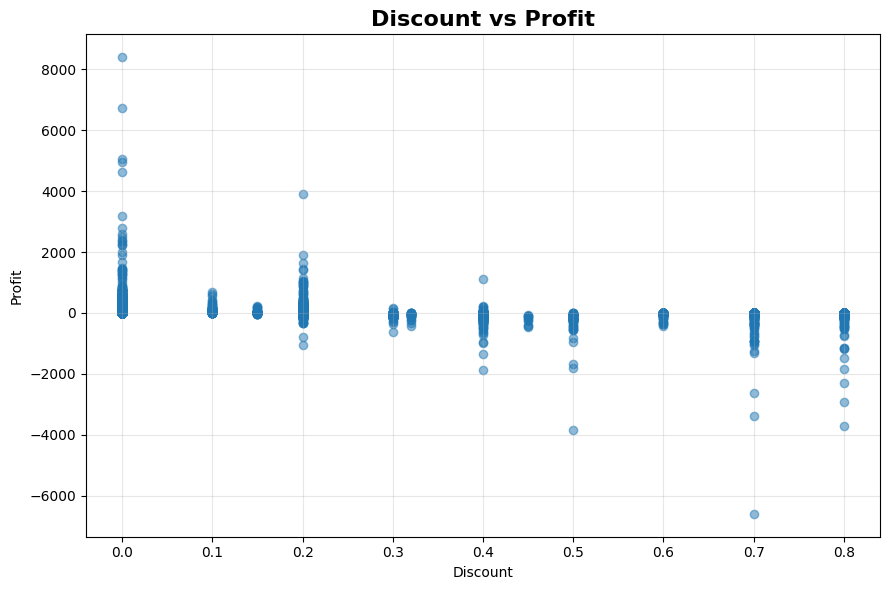

In [36]:
plt.figure(figsize=(9,6))

plt.scatter(
    df_clean["Discount"],
    df_clean["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit", fontsize=16, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

**Profit Status Distribution**

(This visualization compares the number of profitable and loss-making transactions.)

**How are transactions distributed based on their profitability?**

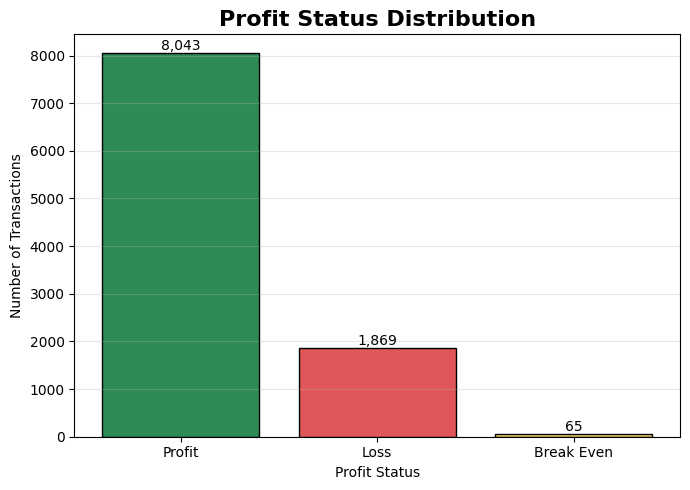

In [37]:
profit_status = (
    df_clean["Profit Status"]
    .value_counts()
)

plt.figure(figsize=(7,5))

colors = ["#2E8B57", "#E15759", "#F1CE63"]

bars = plt.bar(
    profit_status.index,
    profit_status.values,
    color=colors,
    edgecolor="black"
)

plt.title("Profit Status Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Profit Status")
plt.ylabel("Number of Transactions")

plt.grid(axis="y", alpha=0.3)

# Menampilkan jumlah transaksi
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.show()

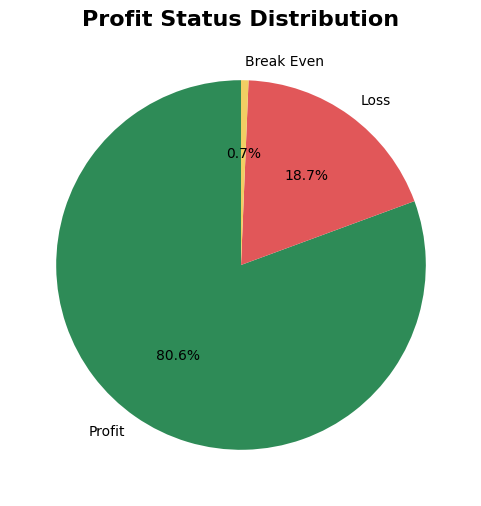

In [38]:
plt.figure(figsize=(6,6))

plt.pie(
    profit_status.values,
    labels=profit_status.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2E8B57", "#E15759", "#F1CE63"]
)

plt.title("Profit Status Distribution", fontsize=16, fontweight="bold")

plt.show()

**Insight**

- The majority of transactions generated positive profit, indicating that most sales contribute positively to the company's financial performance.

- However, a portion of transactions resulted in losses, suggesting that certain products, discount strategies, or regions may require further investigation.

- Understanding the characteristics of loss-making transactions can help management improve pricing strategies and overall profitability.

## **Executive Summary**

### **Overview**

This project analyzes transactional data from an e-commerce company to evaluate sales performance, profitability, and the impact of discounts across different product categories and regions. The objective is to identify business opportunities and provide actionable recommendations to improve overall performance.

The dataset consists of **9,994 sales transactions** with **13 variables**, including customer segment, product category, geographic location, sales amount, quantity, discount, and profit.

### **Key Findings**

- The dataset contains **9,994 transactions** with no missing values, indicating high data completeness.
- A total of **17 duplicate records** were identified during the data cleaning process and removed to improve data quality.
- Initial descriptive statistics show that sales distribution is highly skewed, indicating that a small number of transactions contribute disproportionately to total revenue.
- Profit values vary significantly, with some transactions generating substantial losses, suggesting that certain products or discount strategies may negatively affect profitability.
- Discounts reach up to **80%**, highlighting the need to evaluate whether aggressive discounting contributes to declining profit margins.

### **Business Value**

This analysis provides insights into sales performance, product profitability, and discount effectiveness, enabling management to:

- Identify the most profitable product categories.
- Detect products or regions with consistently low profitability.
- Evaluate the impact of discount policies on business performance.
- Support strategic decisions related to pricing, promotions, and inventory management.

### **Expected Outcome**

The findings from this analysis will support data-driven decision making by helping management optimize sales strategies, improve profitability, and allocate resources more effectively.

##  **Business Insights**

This section summarizes the key findings obtained from the exploratory data analysis. The insights are intended to help management understand current business performance and identify opportunities for improvement.

---

### **1. Sales Performance**

- Summarize the overall sales performance.
- Identify whether sales are concentrated in a few transactions or distributed evenly.
- Highlight any notable trends in transaction values.

**Business Impact**

Understanding the sales distribution helps management identify high-value transactions and optimize sales strategies.

---

### **2. Product Performance**

- Identify the product category with the highest sales.
- Identify the product category with the highest profit.
- Highlight any sub-categories that consistently generate losses.

**Business Impact**

These findings support product portfolio optimization and inventory planning.

---

### **3. Regional Performance**

- Identify the best-performing region based on sales.
- Compare profit across different regions.
- Highlight regions requiring improvement.

**Business Impact**

Regional performance analysis supports market expansion and resource allocation.

---

### **4. Customer Purchasing Pattern**

- Identify purchasing patterns based on customer segments.
- Determine which segment contributes the highest sales and profit.

**Business Impact**

Customer segmentation enables more effective marketing strategies.

---

### **5. Discount Analysis**

- Evaluate the relationship between discounts and profit.
- Identify whether higher discounts reduce profitability.

**Business Impact**

The results provide guidance for designing more effective pricing and promotional strategies.

---

### **6. Profitability Analysis**

- Identify products or transactions generating negative profit.
- Compare profitability across categories and regions.

**Business Impact**

Reducing loss-making transactions can improve the company's overall profitability.

---

### **Summary of Key Findings**

The exploratory data analysis provides valuable insights into sales performance, profitability, regional contribution, product performance, and discount effectiveness. These findings serve as the basis for strategic business recommendations presented in the next section.

## **Key Findings**

1. Technology generated the highest total sales, indicating strong customer demand for technology products.

2. Office Supplies achieved the highest overall profitability despite lower sales than Technology, suggesting better profit margins.

3. The West region contributed the largest share of total revenue and profit, making it the company's strongest market.

4. Tables and Bookcases recorded negative profits despite relatively high sales, indicating pricing or discount issues.

5. Transactions with discounts above 30% tended to produce significantly lower profits, showing that aggressive discounting reduced profitability.

6. Sales distribution was highly right-skewed, with a small number of high-value transactions contributing disproportionately to total revenue.

--------------------------------

---------------------

In [39]:
# ==============================
# Key Performance Indicators
# ==============================

total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_orders = len(df_clean)

avg_profit_margin = (
    (df_clean["Profit"].sum() / df_clean["Sales"].sum()) * 100
)

print(f"Total Sales : ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Orders      : {total_orders:,}")
print(f"Profit Margin: {avg_profit_margin:.2f}%")

Total Sales : $2,296,195.59
Total Profit: $286,241.42
Orders      : 9,977
Profit Margin: 12.47%


In [40]:
fig = plt.figure(figsize=(18,12))

fig.suptitle(
    "E-Commerce Sales Dashboard",
    fontsize=24,
    fontweight="bold"
)

# KPI
fig.text(0.05,0.90,f"💰 Total Sales\n${total_sales:,.0f}",fontsize=16,bbox=dict(facecolor="lightblue"))
fig.text(0.30,0.90,f"📈 Total Profit\n${total_profit:,.0f}",fontsize=16,bbox=dict(facecolor="lightgreen"))
fig.text(0.55,0.90,f"🛒 Orders\n{total_orders:,}",fontsize=16,bbox=dict(facecolor="lightyellow"))
fig.text(0.80,0.90,f"📊 Profit Margin\n{avg_profit_margin:.2f}%",fontsize=16,bbox=dict(facecolor="lightpink"))

plt.show()

<Figure size 1800x1200 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

**HITUNG KPI**

In [42]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_orders = len(df_clean)

profit_margin = total_profit / total_sales * 100

In [43]:
sales_category = df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False)

profit_category = df_clean.groupby("Category")["Profit"].sum().sort_values(ascending=False)

sales_region = df_clean.groupby("Region")["Sales"].sum().sort_values(ascending=False)

top_city = (
    df_clean.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

profit_status = df_clean["Profit Status"].value_counts()

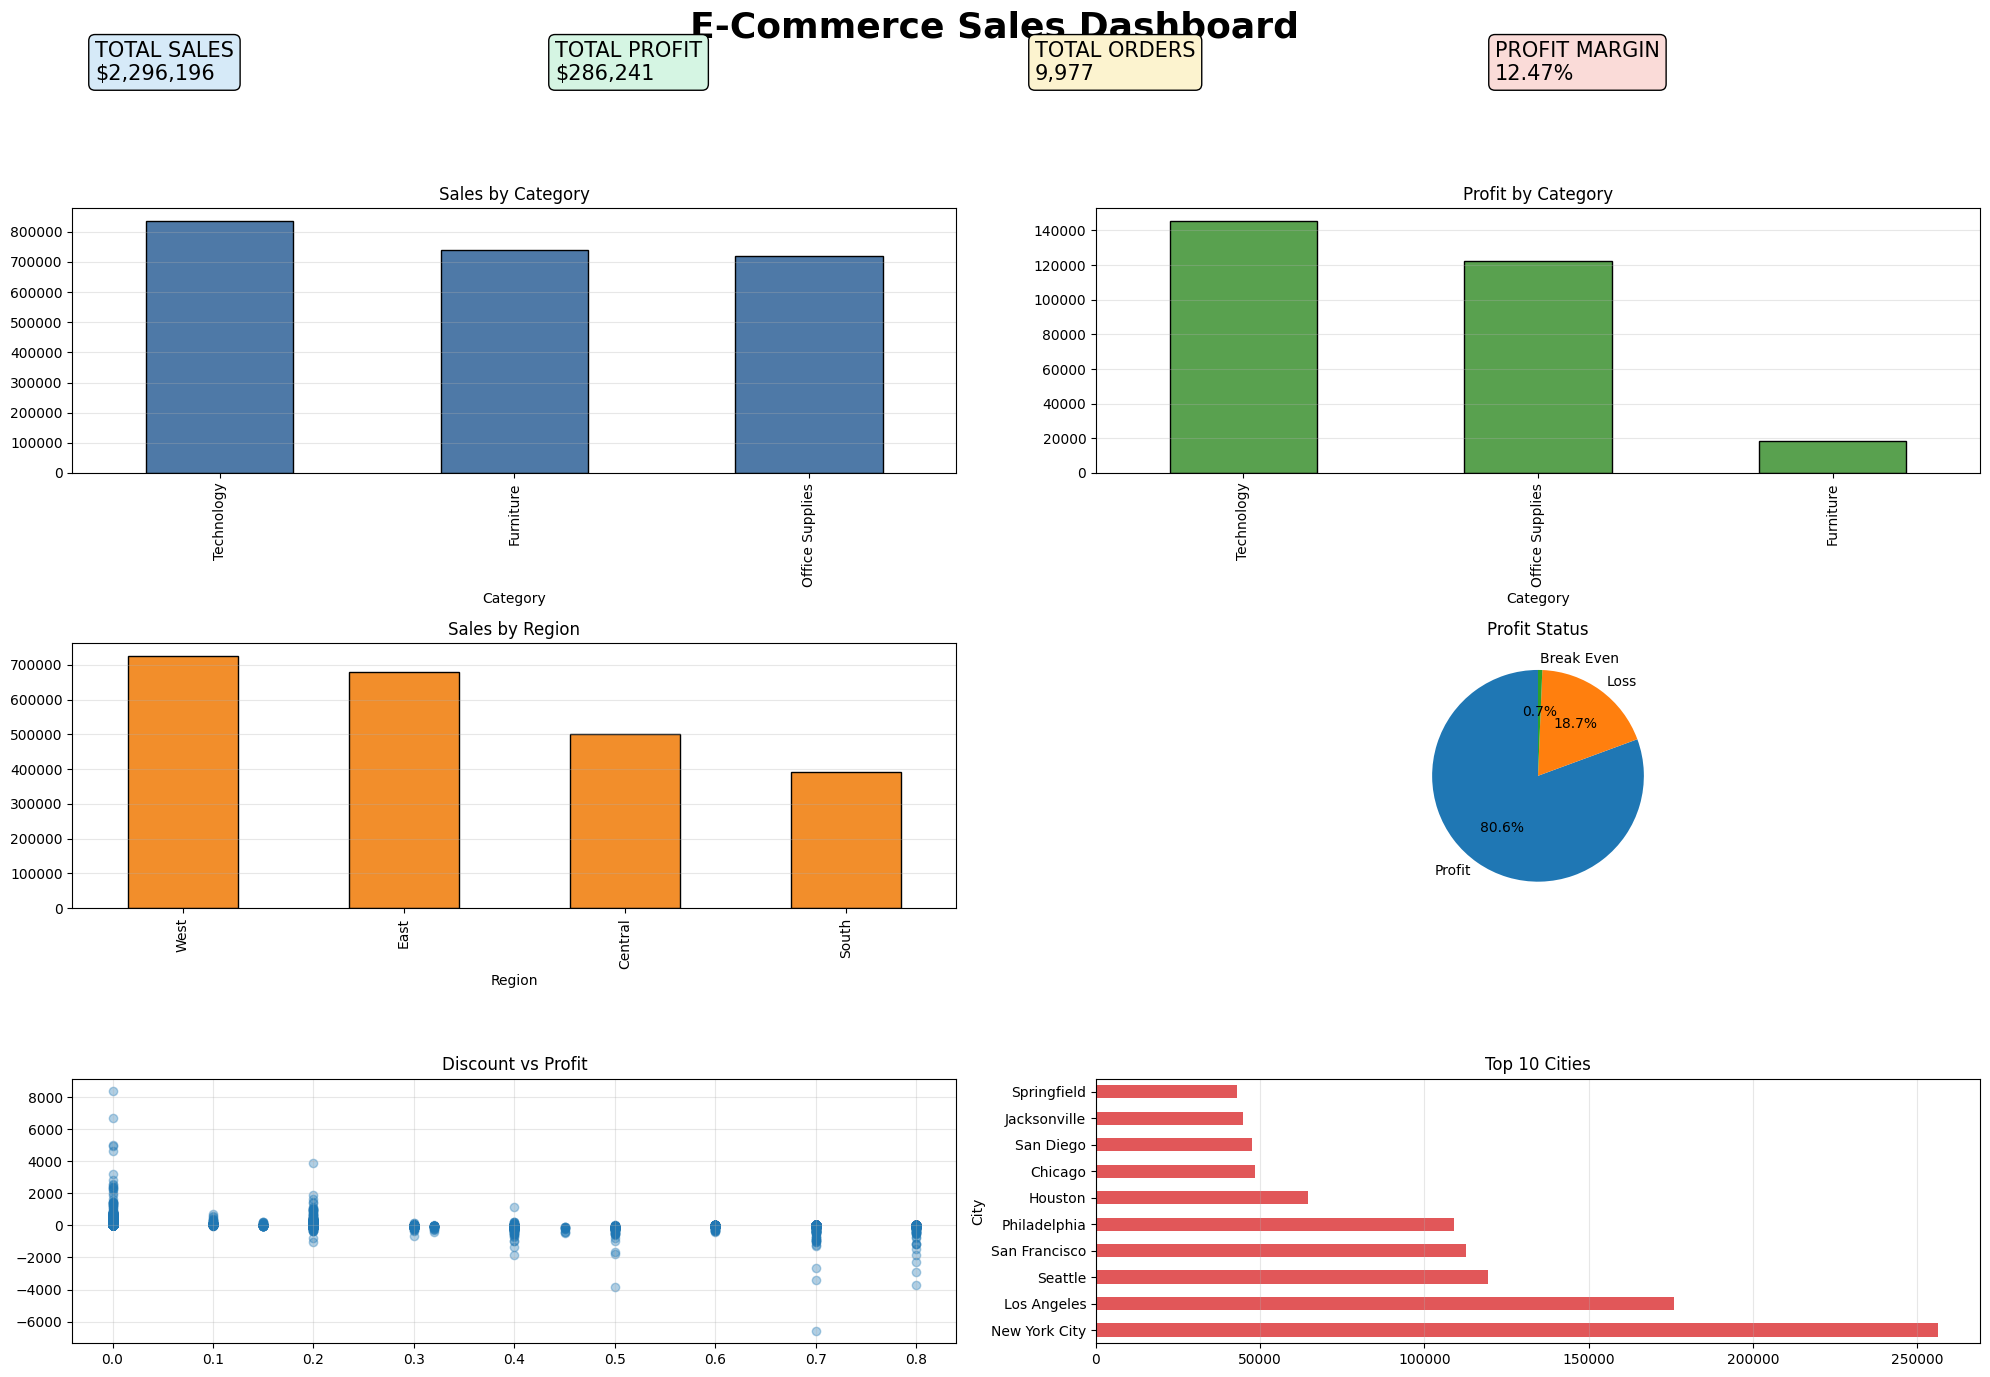

In [44]:
fig = plt.figure(figsize=(20,14))

fig.suptitle(
    "E-Commerce Sales Dashboard",
    fontsize=26,
    fontweight="bold"
)

# ===========================
# KPI Cards
# ===========================

fig.text(
    0.05,0.93,
    f"TOTAL SALES\n${total_sales:,.0f}",
    fontsize=15,
    bbox=dict(facecolor="#D6EAF8",edgecolor="black",boxstyle="round")
)

fig.text(
    0.28,0.93,
    f"TOTAL PROFIT\n${total_profit:,.0f}",
    fontsize=15,
    bbox=dict(facecolor="#D5F5E3",edgecolor="black",boxstyle="round")
)

fig.text(
    0.52,0.93,
    f"TOTAL ORDERS\n{total_orders:,}",
    fontsize=15,
    bbox=dict(facecolor="#FCF3CF",edgecolor="black",boxstyle="round")
)

fig.text(
    0.75,0.93,
    f"PROFIT MARGIN\n{profit_margin:.2f}%",
    fontsize=15,
    bbox=dict(facecolor="#FADBD8",edgecolor="black",boxstyle="round")
)

# ===========================
# Sales by Category
# ===========================

ax1 = plt.subplot(321)

sales_category.plot(
    kind="bar",
    ax=ax1,
    color="#4E79A7",
    edgecolor="black"
)

ax1.set_title("Sales by Category")
ax1.grid(axis="y",alpha=.3)

# ===========================
# Profit by Category
# ===========================

ax2 = plt.subplot(322)

profit_category.plot(
    kind="bar",
    ax=ax2,
    color="#59A14F",
    edgecolor="black"
)

ax2.set_title("Profit by Category")
ax2.grid(axis="y",alpha=.3)

# ===========================
# Sales by Region
# ===========================

ax3 = plt.subplot(323)

sales_region.plot(
    kind="bar",
    ax=ax3,
    color="#F28E2B",
    edgecolor="black"
)

ax3.set_title("Sales by Region")
ax3.grid(axis="y",alpha=.3)

# ===========================
# Profit Status
# ===========================

ax4 = plt.subplot(324)

profit_status.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ax=ax4
)

ax4.set_ylabel("")
ax4.set_title("Profit Status")

# ===========================
# Discount vs Profit
# ===========================

ax5 = plt.subplot(325)

ax5.scatter(
    df_clean["Discount"],
    df_clean["Profit"],
    alpha=.35
)

ax5.set_title("Discount vs Profit")
ax5.grid(alpha=.3)

# ===========================
# Top Cities
# ===========================

ax6 = plt.subplot(326)

top_city.plot(
    kind="barh",
    ax=ax6,
    color="#E15759"
)

ax6.set_title("Top 10 Cities")
ax6.grid(axis="x",alpha=.3)

plt.tight_layout(rect=[0,0,1,.90])

plt.savefig(
    "dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

In [46]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_orders = len(df_clean)
profit_margin = total_profit / total_sales * 100

sales_category = (
    df_clean.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

profit_category = (
    df_clean.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

sales_region = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_city = (
    df_clean.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

profit_status = df_clean["Profit Status"].value_counts()

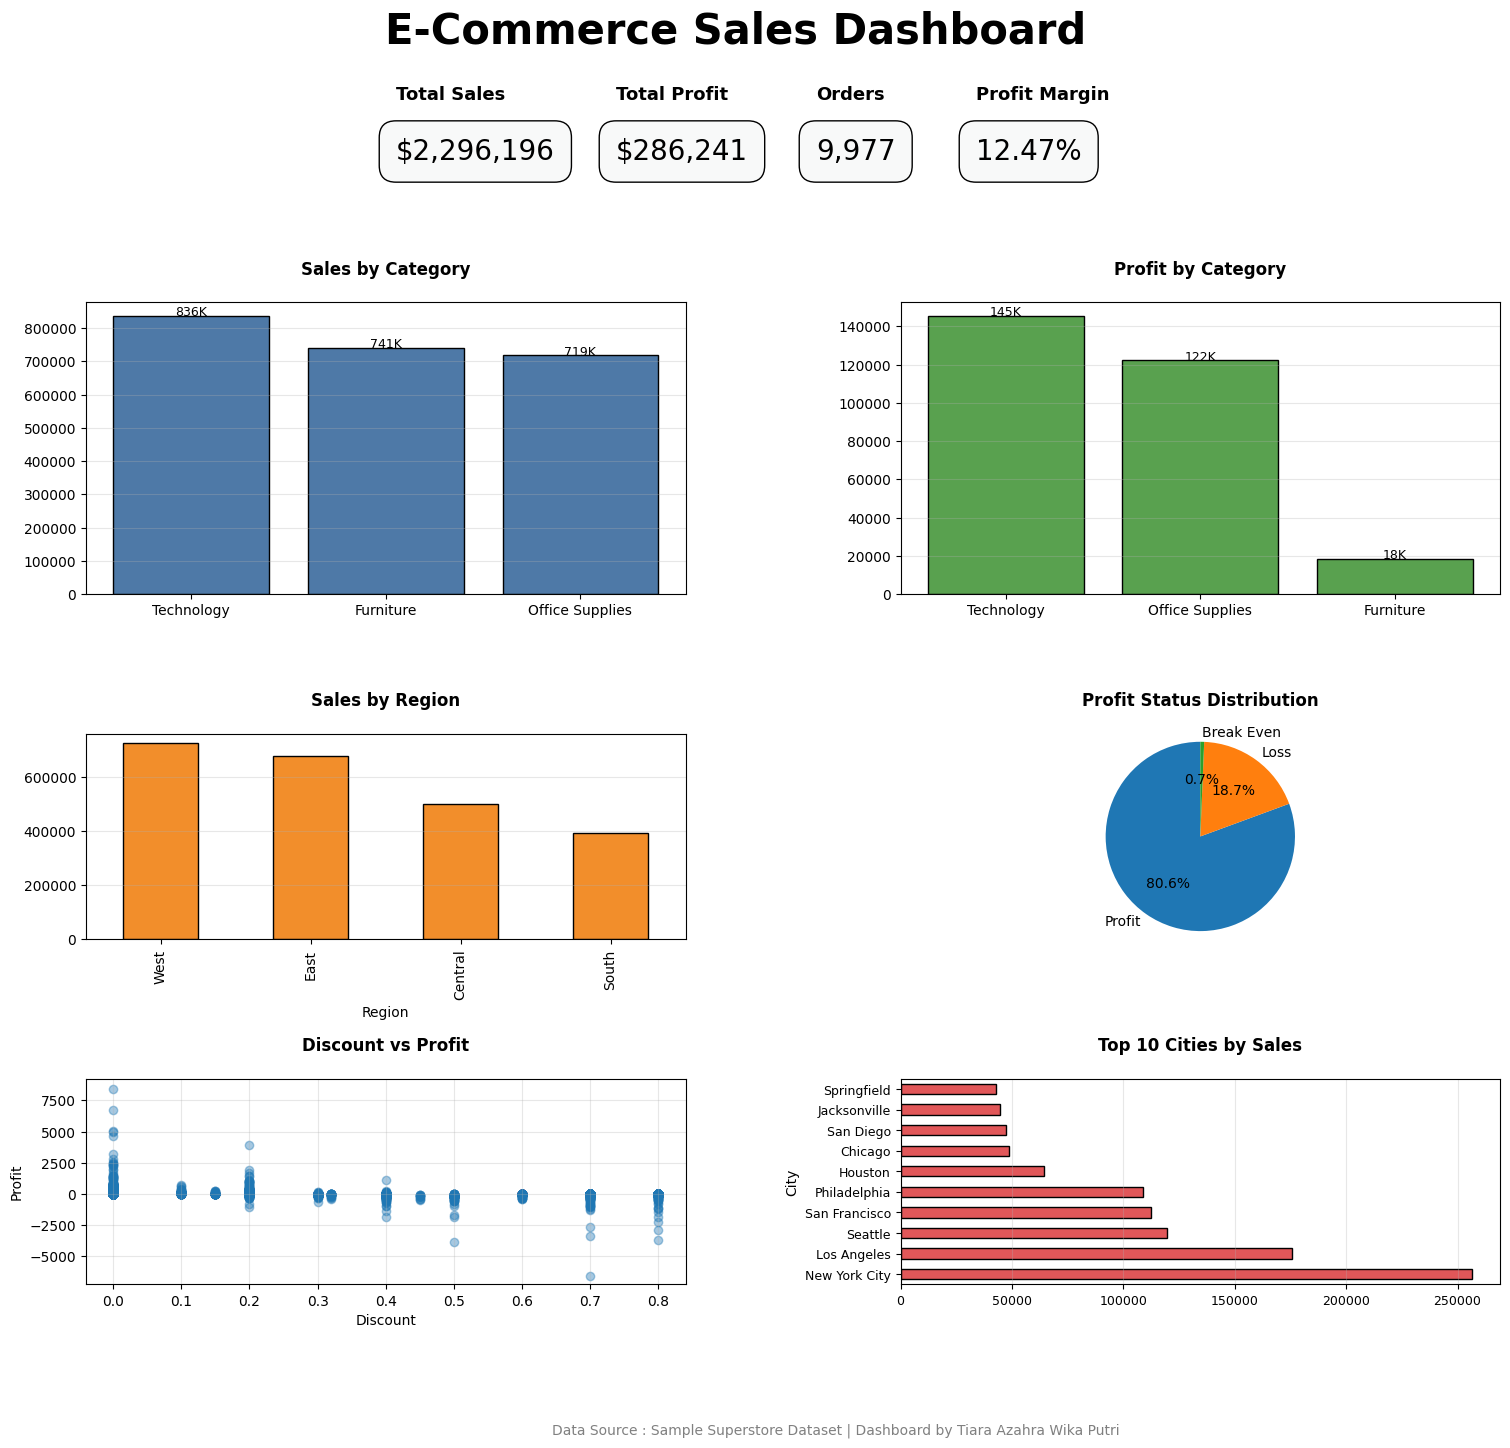

In [94]:
# ==========================================
# Executive Dashboard
# ==========================================

fig = plt.figure(figsize=(20,15))

gs = GridSpec(
    nrows=14,
    ncols=12,
    figure=fig,
    hspace=1.6,
    wspace=1.4
)

fig.text(
    0.45,          # tengah horizontal
    0.96,        # posisi vertikal
    "E-Commerce Sales Dashboard",
    ha="center",
    va="top",
    fontsize=30,
    fontweight="bold"
)

# ==================================================
# KPI CARDS
# ==================================================

card_color = "#F8F9F9"

cards = [
    ("Total Sales", f"${total_sales:,.0f}", 0.28),
    ("Total Profit", f"${total_profit:,.0f}", 0.39),
    ("Orders", f"{total_orders:,}", 0.49),
    ("Profit Margin", f"{profit_margin:.2f}%", 0.57)
]

for title, value, x in cards:

    fig.text(
        x,
        .90,
        title,
        fontsize=13,
        fontweight="bold"
    )

    fig.text(
        x,
        .86,
        value,
        fontsize=20,
        bbox=dict(
            facecolor=card_color,
            edgecolor="black",
            boxstyle="round,pad=.6"
        )
    )

# ==========================================
# Sales by Category
# ==========================================

ax1 = fig.add_subplot(gs[2:6,0:5])

bars=ax1.bar(
    sales_category.index,
    sales_category.values,
    color="#4E79A7",
    edgecolor="black"
)

ax1.set_title("Sales by Category",fontweight="bold", pad=20)

ax1.grid(axis="y",alpha=.3)

for bar in bars:

    ax1.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height()/1000:.0f}K",
        ha="center",
        fontsize=9
    )

# ==========================================
# Profit by Category
# ==========================================

ax2 = fig.add_subplot(gs[2:6,6:11])

bars=ax2.bar(
    profit_category.index,
    profit_category.values,
    color="#59A14F",
    edgecolor="black"
)

ax2.set_title("Profit by Category",fontweight="bold", pad=20)

ax2.grid(axis="y",alpha=.3)

for bar in bars:

    ax2.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height()/1000:.0f}K",
        ha="center",
        fontsize=9
    )

# ==========================================
# Sales by Region
# ==========================================

ax3 = fig.add_subplot(gs[7:10,0:5])

sales_region.plot(
    kind="bar",
    color="#F28E2B",
    edgecolor="black",
    ax=ax3
)

ax3.set_title("Sales by Region",fontweight="bold", pad=20)

ax3.grid(axis="y",alpha=.3)

# ==========================================
# Profit Status
# ==========================================

ax4 = fig.add_subplot(gs[7:10,6:11])

ax4.pie(
    profit_status.values,
    labels=profit_status.index,
    autopct="%1.1f%%",
    startangle=90,
    radius=1.15,
    textprops={"fontsize":10}
)

ax4.set_title("Profit Status Distribution",fontweight="bold", pad=20)

# ==========================================
# Discount vs Profit
# ==========================================

ax5 = fig.add_subplot(gs[11:14,0:5])

ax5.scatter(
    df_clean["Discount"],
    df_clean["Profit"],
    alpha=.4
)

ax5.set_title("Discount vs Profit",fontweight="bold", pad=20)

ax5.set_xlabel("Discount")

ax5.set_ylabel("Profit")

ax5.grid(alpha=.3)

ax5.set_ylim(
    df_clean["Profit"].min()*1.1,
    df_clean["Profit"].max()*1.1
)

# ==========================================
# Top Cities
# ==========================================

ax6 = fig.add_subplot(gs[11:14,6:11])

top_city.plot(
    kind="barh",
    color="#E15759",
    edgecolor="black",
    ax=ax6
)

ax6.set_title("Top 10 Cities by Sales",fontweight="bold", pad=20)

ax6.grid(axis="x",alpha=.3)

ax6.tick_params(labelsize=9)


# ==========================================
# Footer
# ==========================================

fig.text(
    .5,
    .01,
    "Data Source : Sample Superstore Dataset | Dashboard by Tiara Azahra Wika Putri",
    ha="center",
    fontsize=10,
    color="gray"
)

plt.savefig(
    "dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()